In [2]:
import numpy as np
import matplotlib.pyplot as plt


def calculate_lj_properties(r_sq, r_cutoff_sq):
    """
    Calculates reduced potential energy and force magnitude for a pair of atoms.
    Implements the shifted Lennard-Jones potential: phi(r) - phi(rc).
    Returns (potE, force/r).
    """
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)

    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    phi = 4 * (inv_r12 - inv_r6)

    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)
    force_by_rc = 48 * inv_rc2 * (inv_rc12 - 0.5 * inv_rc6)
    force_by_r = force_by_r - force_by_rc
    potE = phi - phi_cut + 0.5 * force_by_rc * (r_sq - r_cutoff_sq)

    return potE, force_by_r


def generate_fcc_lattice(n_cells, rho_star):
    """
    Generates an FCC lattice of atoms.
    Returns (positions array of shape (N,3), box length L).
    N = 4 * n_cells^3.
    """
    L = (4 * n_cells**3 / rho_star) ** (1 / 3)
    a = L / n_cells
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)
    return np.array(positions), L


def apply_minimum_image(pos_i, pos_j, L):
    """
    Calculates the shortest distance vector between two atoms using
    the minimum image convention. dx, dy, dz are kept in [-L/2, L/2].
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr


def calculate_total_force(pos, box_length, r_cutoff_sq):
    """Returns (total_pe, forces array of shape (N,3))."""
    N = len(pos)
    forces = np.zeros((N, 3))
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr**2, axis=2)
    r_sq = np.triu(r_sq, k=1)
    mask = (r_sq < r_cutoff_sq) & (r_sq > 0)
    pot, force_by_r = np.zeros_like(r_sq), np.zeros_like(r_sq)
    pot[mask], force_by_r[mask] = calculate_lj_properties(r_sq[mask], r_cutoff_sq)
    f_mat = force_by_r[:, :, np.newaxis] * dr
    forces += np.sum(f_mat, axis=0)
    forces -= np.sum(f_mat, axis=1)
    total_pe = np.sum(pot)
    return total_pe, forces


def calculate_kinetic_energy(vel):
    """K* = 0.5 * sum(v²)  [m* = 1 in reduced units]"""
    return 0.5 * np.sum(vel**2)


def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs (i, j) within the skin radius.
    Uses the Minimum Image Convention. Fully vectorized.
    """
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], L)
    r_sq = np.sum(dr**2, axis=2)
    i_idx, j_idx = np.where(np.triu(r_sq < r_skin_sq, k=1))
    return np.stack([i_idx, j_idx], axis=1)


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using only the pairs in the neighbor list.
    Returns (total_pe, forces array of shape (N,3)).
    """
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0.0
    if len(neighbor_pairs) == 0:
        return total_pe, forces

    i_idx = neighbor_pairs[:, 0]
    j_idx = neighbor_pairs[:, 1]

    dr = apply_minimum_image(pos[i_idx], pos[j_idx], L)
    r_sq = np.sum(dr**2, axis=1)

    mask = r_sq < r_cutoff_sq
    pot, force_by_r = calculate_lj_properties(r_sq[mask], r_cutoff_sq)

    f_vec = force_by_r[:, np.newaxis] * dr[mask]
    np.add.at(forces, i_idx[mask], -f_vec)
    np.add.at(forces, j_idx[mask],  f_vec)
    total_pe = np.sum(pot)
    return total_pe, forces


def velocity_verlet_step_opt(pos, vel, force, dt, box_length, r_cutoff_sq, neighbour_list):
    """
    Velocity Verlet step using the optimized neighbor-list force calculation.
    Returns (pos_new, vel_new, pe_new, force_new).
    """
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    pos_new = pos_new % box_length
    vel_mid = vel + 0.5 * force * dt
    pe_new, force_new = calculate_forces_optimized(pos_new, neighbour_list, box_length, r_cutoff_sq)
    vel_new = vel_mid + 0.5 * force_new * dt
    return pos_new, vel_new, pe_new, force_new

def initialize_velocities(N, T_target):
    """
    Assigns initial velocities from a Maxwell-Boltzmann distribution.
    Generates a (N, 3) array with std_dev = sqrt(T_target),
    then removes net momentum so the center-of-mass is stationary.
    """
    sigma = np.sqrt(T_target)
    vel = np.random.normal(loc=0.0, scale=sigma, size=(N, 3))
    vel -= vel.mean(axis=0)  
    return vel

def rescale_velocities ( vel , T_target ) :

    """
    Scales velocities to match the target temperature .
    """
    # 1. Calculate current T_inst = (sum v^2) / 3N
    # 2. Scale factor lambda = sqrt ( T_target / T_inst )
    # 3. vel = vel * lambda
    T_inst = np.sum(vel**2) / (3 * len(vel))
    lambda_factor = np.sqrt(T_target / T_inst)
    vel *= lambda_factor
    return vel

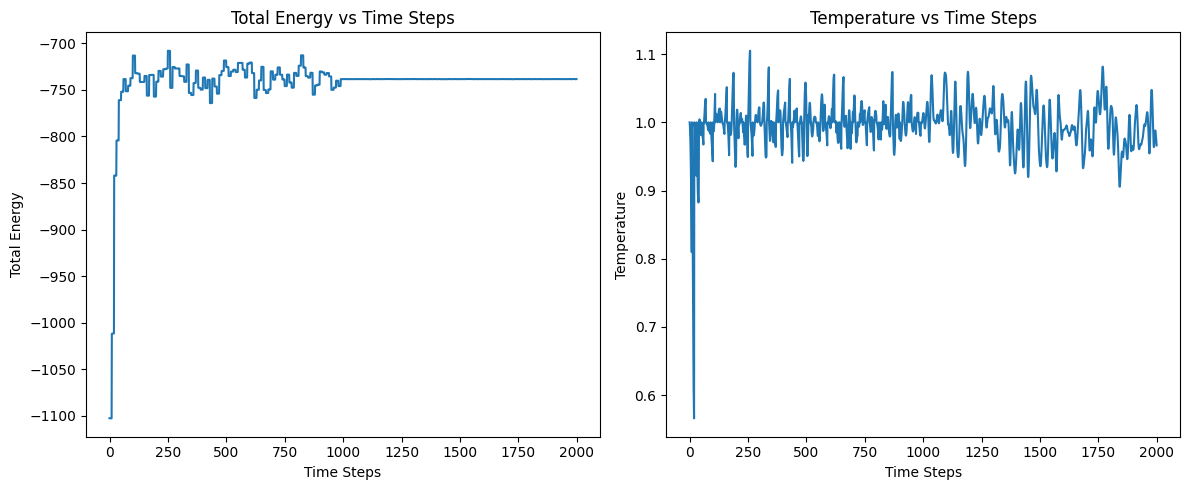

In [3]:
# --- THE MAIN MD LOOP ---
# 1. Setup: Define n_cells, density, T_target, dt, and steps.
# 2. Initialize: Call generate_fcc_lattice and initialize_velocities.
# 3. Main Loop:
#    - Call velocity_verlet_step (from Module 4)
#    - If in equilibration and step % 10 == 0: call rescale_velocities
#    - Accumulate energy and temperature data for plotting.

n_cells     = 4        
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff**2
r_skin     = 3.2
r_skin_sq = r_skin**2

pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)
pos_ref = pos.copy()
vel    = initialize_velocities(N, T_target)

# Initial forces

energies     = []
temperatures = []
neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2   # (0.7/2)^2 = 0.1225

for step in range(total_steps):
    pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq,neighbour_list)

    disp_sq = np.sum((pos - pos_ref)**2, axis=1)
    if np.any(disp_sq > rebuild_threshold_sq):
        neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
        pos_ref = pos.copy()


    # Rescale velocities every 10 steps during equilibration (first half)
    if step < total_steps // 2 and step % 10 == 0:
        vel = rescale_velocities(vel, T_target)

    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)
    temperatures.append(2 * ke / (3 * N))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(energies)
plt.title('Total Energy vs Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Total Energy')
plt.subplot(1, 2, 2)
plt.plot(temperatures)
plt.title('Temperature vs Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Temperature') 
plt.tight_layout()
plt.show()


In [4]:
# --- Module 6 Coding Task : Final Analysis ---
import numpy as np
import matplotlib . pyplot as plt

def calculate_rdf ( pos , box_length , dr , r_max ):
    """
    Calculates the Radial Distribution Function g(r).
    TASK :
    1. Loop through all pairs and calculate distance r using MIC .
    2. Sort distances into a histogram with bin width dr.
    3. Normalize by the volume of the spherical shells and density .
    """
    # --- YOUR CODE HERE ---
    N = len(pos)

    n_bins = int(np.round(r_max / dr))
    g_hist = np.zeros(n_bins)

    dr_vec = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr_vec**2, axis=2)
    r_dist = np.sqrt(r_sq[np.triu_indices(N, k=1)])
    valid_dist = r_dist[r_dist < r_max]

    k = (valid_dist / dr).astype(int)

    cnt = np.bincount(k, minlength=n_bins)
    g_hist += cnt

    r_centers = (np.arange(n_bins) + 0.5) * dr
    shell_vol = 4 * np.pi * (r_centers**2) * dr

    g_r = (2.0 * g_hist * ((box_length)**3)) / (N * N * shell_vol)
    
    return r_centers, g_r

Running simulation for T* = 0.2...
Running simulation for T* = 0.4...
Running simulation for T* = 0.6...
Running simulation for T* = 0.8...
Running simulation for T* = 1.0...


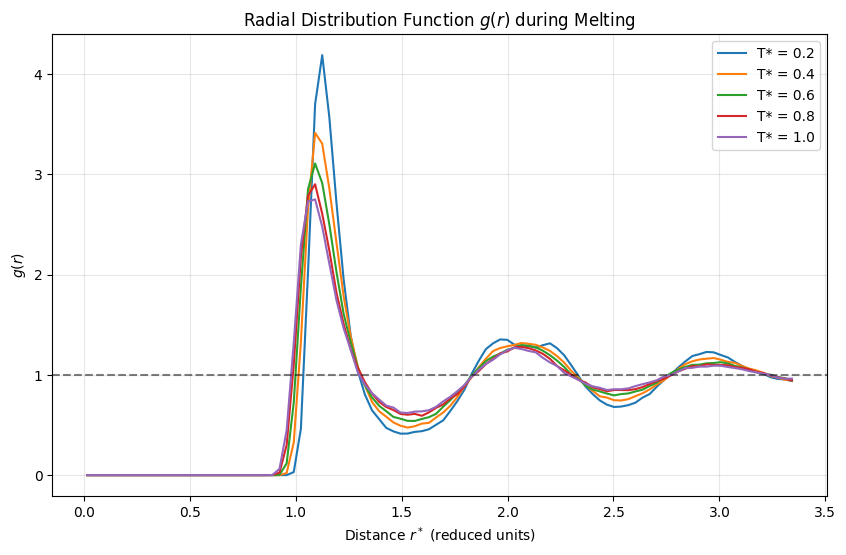

In [9]:
# --- THE FINAL PROJECT CHALLENGE: Melting ---
temperatures = [0.2, 0.4, 0.6, 0.8, 1.0]
equilibration_steps = 1000
production_steps = 1000
dt = 0.005
r_max = L / 2.0  # Max distance is half the box length
dr = r_max / 100.0  # 100 bins

plt.figure(figsize=(10, 6))

for T_target in temperatures:
    print(f"Running simulation for T* = {T_target}...")
    
    # Re-initialize for each temperature run to simulate the stepping process 
    # (or you can carry the positions over to naturally melt it, but scaling velocities is safer here)
    vel = initialize_velocities(N, T_target)
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    
    # 1. Equilibration Phase
    for step in range(equilibration_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        # Update neighbor list if atoms moved too far
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Velocity rescaling thermostat
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # 2. Production Phase (Collect g(r) data)
    g_r_accumulated = np.zeros(int(r_max/dr))
    collection_count = 0
    
    for step in range(production_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Collect g(r) periodically to avoid highly correlated data (e.g., every 10 steps)
        if step % 10 == 0:
            r_centers, g_r_current = calculate_rdf(pos, L, dr, r_max)
            g_r_accumulated += g_r_current
            collection_count += 1
            
    # Average the collected g(r) data
    g_r_avg = g_r_accumulated / collection_count
    
    # Plot this temperature's g(r)
    # NOTE: Before final submission, multiply r_centers by your chosen gas's sigma (in Å)
    plt.plot(r_centers, g_r_avg, label=f'T* = {T_target}')

# Finalize the plot
plt.title('Radial Distribution Function $g(r)$ during Melting')
plt.xlabel('Distance $r^*$ (reduced units)') # Change to Å for final submission
plt.ylabel('$g(r)$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5) # Asymptote reference line
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running for Krypton at T* = 0.4  (≈ 65 K)...


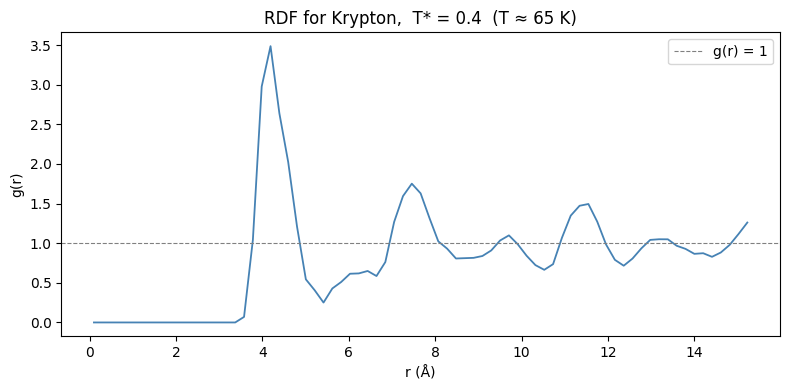

  At 65 K, expect sharp peaks (solid)
Running for Krypton at T* = 1.0  (≈ 162 K)...


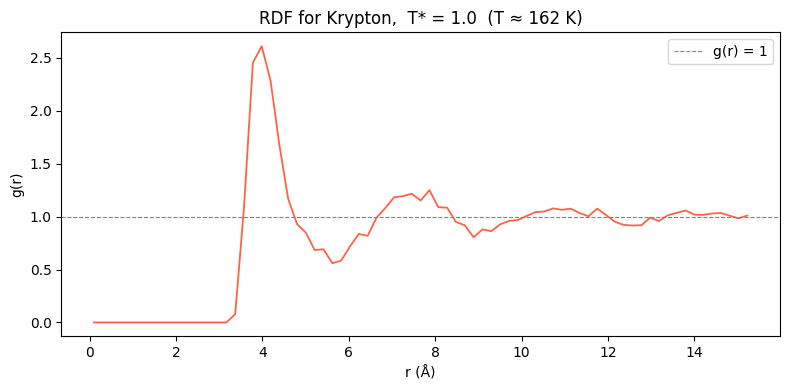

  At 162 K, expect broad peaks decaying to 1.0 (liquid)


In [5]:
eV_to_K        = 11604.52
eps_over_kB_Kr = 0.0140 * eV_to_K    # 162.46 K
sigma_Kr_A     = 3.65                 # Angstroms


n_cells     = 5   
rho_star    = 0.8442
dt          = 0.005
total_steps = 4000
equil_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff**2
r_skin      = 3.2
r_skin_sq   = r_skin**2
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2

for T_target in [0.4, 1.0]:
    T_real_K = T_target * eps_over_kB_Kr
    print(f"Running for Krypton at T* = {T_target}  (≈ {T_real_K:.0f} K)...")

    pos, L    = generate_fcc_lattice(n_cells, rho_star)
    N         = len(pos)
    pos_ref   = pos.copy()
    vel       = initialize_velocities(N, T_target)
    nb        = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, nb, L, r_cutoff_sq)

    # --- Run loop ---
    for step in range(total_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(
            pos, vel, force, dt, L, r_cutoff_sq, nb)

        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            nb      = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()

        if step < equil_steps and step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    r_max  = L / 2.0
    n_bins = 75
    dr     = r_max / n_bins

    r_centers, g_r = calculate_rdf(pos, L, dr, r_max)
    r_angstrom = r_centers * sigma_Kr_A

    plt.figure(figsize=(8, 4))
    plt.plot(r_angstrom, g_r, linewidth=1.3,
             color='steelblue' if T_target == 0.4 else 'tomato')
    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='g(r) = 1')
    plt.xlabel('r (Å)')
    plt.ylabel('g(r)')
    plt.title(f'RDF for Krypton,  T* = {T_target}  (T ≈ {T_real_K:.0f} K)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if T_target == 0.4:
        print(f"  At {T_real_K:.0f} K, expect sharp peaks (solid)")
    else:
        print(f"  At {T_real_K:.0f} K, expect broad peaks decaying to 1.0 (liquid)")